### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [4]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [5]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [6]:
arxiv.invoke("Attention is all you need")

AttributeError: 'Search' object has no attribute 'results'

In [8]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [9]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [11]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\harsh\AppData\Local\Temp\ipykernel_12616\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [12]:
tavily.invoke("Provide me the recent AI news for july 15th 2026")

[{'title': 'Daily AI & Data News Summary – 15 July 2026',
  'url': 'https://www.reddit.com/r/DecodingDataSciAI/comments/1uwwv0i/daily_ai_data_news_summary_15_july_2026',
  'content': "🔹 U.S. launches AI-Cybersecurity Coordination Group The White House has announced a new AI-Cybersecurity Coordination Group that will connect leading AI companies with critical infrastructure providers to share AI-discovered vulnerabilities and strengthen national cyber defenses. OpenAI, Anthropic, Meta, NVIDIA, and other major AI companies are expected to participate. 🔹 DeepMind CEO calls for an independent global AI safety body Google DeepMind CEO Demis Hassabis has urged governments to establish an independent international organization to evaluate frontier AI models before deployment. The proposal reflects growing concern that AI capabilities are advancing faster than global governance frameworks. 🔹 OpenAI researcher reportedly launches $2B AI drug discovery startup OpenAI researcher [...] launches $2

In [13]:
### Combine all the tools in the list

# tools=[arxiv,wiki,tavily]
tools=[wiki,tavily]

In [16]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")

llm_with_tools=llm.bind_tools(tools)

In [17]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': "I will search for the latest news related to Artificial Intelligence, covering major developments, new model releases, and significant industry updates.\nFinally, I will answer the user's question about recent AI news based on the gathered information.\n", 'tool_calls': [{'id': '0zz7z3z7f', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 409, 'total_tokens': 488, 'completion_time': 0.151303694, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.03079655, 'prompt_tokens_details': None, 'queue_time': 0.05292155, 'total_time': 0.182100244}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_fff3b79855', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6f43-c918-7602-a5f6-65ccdfc6082

In [18]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'v2zmh6zhc',
  'type': 'tool_call'}]

In [19]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

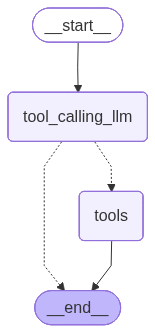

In [20]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [21]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (47dxapzw0)
 Call ID: 47dxapzw0
  Args:
    query: arXiv 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "[1706.03762] Attention Is All You Need", "url": "https://arxiv.org/abs/1706.03762", "content": "archive\n\n# Computer Science > Computation and Language\n\n# Title:Attention Is All You Need\n\n|  |  |\n --- |\n| Comments: | 15 pages, 5 figures |\n| Subjects: | Computation and Language (cs.CL); Machine Learning (cs.LG) |\n| Cite as: | arXiv:1706.03762 [cs.CL] |\n|  | (or  arXiv:1706.03762v7 [cs.CL] for this version) |\n|  |  Focus to learn more  arXiv-issued DOI via DataCite |\n\n## Submission history\n\n## Access Paper:\n\n### Current browse context:\n\n### References & Citations\n\n

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (0vq2mjqan)
 Call ID: 0vq2mjqan
  Args:
    query: top 10 AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 10 Biggest AI News Stories Of 2025", "url": "https://www.crn.com/news/ai/2025/the-10-biggest-ai-news-stories-of-2025", "content": "# The 10 Biggest AI News Stories Of 2025\n\nThe AI industry in 2025 saw big-money acquisitions, advancements in virtual assistants and agent orchestration, and new innovations in hardware.\n\nTechnological Iceberg as the beginning of Artificial Intelligence and the new tech advent investment or hidden uncertainty of AI that lies beneath the surface with 3D illustration elements.\n\nBig-money acqu

In [23]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a branch of Artificial Intelligence (AI) that focuses on the development of algorithms that allow computers to learn from and make decisions or predictions based on data.

In simpler terms: Instead of a human explicitly programming a computer to perform a specific task (like "if you see this image, label it a cat"), machine learning allows the computer to figure out the rules itself by looking at examples.

### How It Works: Traditional vs. Machine Learning

To understand ML, it helps to compare it to traditional programming.

*   **Traditional Programming:** You provide the **Data** and the **Rules** (Code), and the computer gives you **Answers**.
    *   *Example:* You write code that says, "If the string contains 'Buy Now' and 'Free', mark it as Spam."
*   **Machine Le